In [26]:
import numpy as np
from sklearn.linear_model import Ridge
import time

# --- 1. ESN Parameters (from our last stable attempt) ---
N_RESERVOIR = 1024
N_INPUT = 3
N_OUTPUT = 3
SPECTRAL_RADIUS = 1.2  # Keep the "energy" high
SPARSITY = 0.95
LEAK_RATE = 0.3        # Keep the leaky integration

# --- 2. Load the Dataset ---
print("Loading Chua dataset...")
u_data = np.load("chua_3d_inputs.npy")
d_data = np.load("chua_3d_targets.npy")
N_SAMPLES = u_data.shape[0]
print(f"Dataset loaded: {N_SAMPLES} samples.")

# --- 3. Create the Canonical ESN Reservoir ---
print("Creating canonical ESN reservoir...")
# (We need to save/load this to ensure all passes use the *same* reservoir)
try:
    W_in = np.load("W_in_canonical.npy")
    W_res = np.load("W_res_canonical.npy")
    print("  Loaded existing canonical W_in and W_res.")
except FileNotFoundError:
    print("  No existing matrices found. Generating new ones...")
    W_in = np.random.rand(N_RESERVOIR, N_INPUT) * 2 - 1
    W_in *= 0.1
    W_res = np.random.rand(N_RESERVOIR, N_RESERVOIR) * 2 - 1
    zero_indices = np.random.rand(*W_res.shape) < SPARSITY
    W_res[zero_indices] = 0
    eigenvalues = np.linalg.eigvals(W_res)
    current_radius = np.max(np.abs(eigenvalues))
    W_res *= (SPECTRAL_RADIUS / current_radius)
    np.save("W_in_canonical.npy", W_in)
    np.save("W_res_canonical.npy", W_res)
    print("  New canonical W_in and W_res saved.")
    
print(f"  Reservoir spectral radius: {np.max(np.abs(np.linalg.eigvals(W_res))):.4f}")

# Define our activation function
def activation_func(x):
    return np.tanh(x)

# --- 4. PASS 1: Train "W_out_v1" on perfect data ---
print("\n--- TRAINING PASS 1: (Perfect Data) ---")
R_states_v1 = np.zeros((N_SAMPLES, N_RESERVOIR))
r_current = np.zeros(N_RESERVOIR)

start_time = time.time()
for i in range(N_SAMPLES):
    u_next = u_data[i]
    r_next_linear = W_res @ r_current + W_in @ u_next
    r_activated = activation_func(r_next_linear)
    r_current = (1 - LEAK_RATE) * r_current + LEAK_RATE * r_activated
    R_states_v1[i] = r_current

print(f"  Pass 1 state collection finished in {time.time() - start_time:.2f}s.")

# Train W_out_v1
reg_v1 = Ridge(alpha=1e-6, fit_intercept=False)
reg_v1.fit(R_states_v1, d_data)
W_out_v1 = reg_v1.coef_
print("  W_out_v1 (draft model) trained.")

# --- 5. PASS 2: Train "W_out_final" with Scheduled Sampling ---
print("\n--- TRAINING PASS 2: (Scheduled Sampling) ---")
# This is our novel "gradient-free" scheduled sampling
# We will force the ESN to see its own errors 50% of the time.
SAMPLING_PROBABILITY = 0.5  # 50% chance to use its own prediction

R_states_v2 = np.zeros((N_SAMPLES, N_RESERVOIR))
r_current = np.zeros(N_RESERVOIR)
u_current = u_data[0] # Start with the first real data point

start_time = time.time()
for i in range(N_SAMPLES - 1):
    # ESN update
    r_next_linear = W_res @ r_current + W_in @ u_current
    r_activated = activation_func(r_next_linear)
    r_current = (1 - LEAK_RATE) * r_current + LEAK_RATE * r_activated
    R_states_v2[i] = r_current
    
    # --- Scheduled Sampling Logic ---
    if np.random.rand() < SAMPLING_PROBABILITY:
        # "Teacher Forcing": Use the perfect ground-truth data
        u_current = u_data[i+1]
    else:
        # "Generative Mode": Use the model's *own prediction* as the next input
        # We use the W_out_v1 we just trained to make this prediction
        u_current = W_out_v1 @ r_current 
        
print(f"  Pass 2 state collection finished in {time.time() - start_time:.2f}s.")
# We have one less state, so we trim the targets
R_states_v2 = R_states_v2[:-1]
d_data_trimmed = d_data[:-1]

# Train the FINAL W_out
print("  Training W_out_final on 'dirty' states...")
reg_final = Ridge(alpha=1e-6, fit_intercept=False)
reg_final.fit(R_states_v2, d_data_trimmed)
W_out_final = reg_final.coef_
print("  W_out_final (final model) trained.")

# --- 6. Save the Final Model ---
np.save("W_out_chua_final.npy", W_out_final)
print("\nSuccessfully trained and saved 'W_out_chua_final.npy'.")
print("This model is now robust to exposure bias.")

Loading Chua dataset...
Dataset loaded: 100000 samples.
Creating canonical ESN reservoir...
  Loaded existing canonical W_in and W_res.
  Reservoir spectral radius: 1.2000

--- TRAINING PASS 1: (Perfect Data) ---
  Pass 1 state collection finished in 17.15s.
  W_out_v1 (draft model) trained.

--- TRAINING PASS 2: (Scheduled Sampling) ---
  Pass 2 state collection finished in 17.47s.
  Training W_out_final on 'dirty' states...
  W_out_final (final model) trained.

Successfully trained and saved 'W_out_chua_final.npy'.
This model is now robust to exposure bias.


Loading canonical W_in, W_res, and FINAL W_out...
Matrices loaded.
Running ESN in generative mode...
Generation complete.
Plotting the ESN-generated attractor...


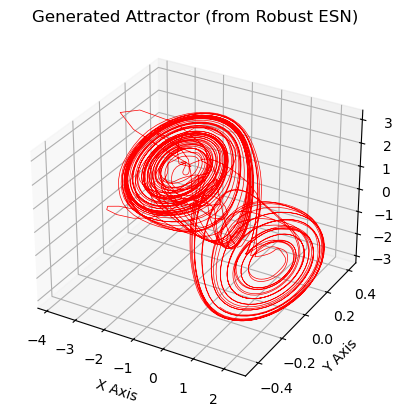

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load FINAL ESN Matrices ---
print("Loading canonical W_in, W_res, and FINAL W_out...")
W_in = np.load("W_in_canonical.npy")
W_res = np.load("W_res_canonical.npy")
W_out = np.load("W_out_chua_final.npy") # <--- Loading the new robust model
print("Matrices loaded.")

N_RESERVOIR = W_res.shape[0]
LEAK_RATE = 0.3  # MUST MATCH THE TRAINING SCRIPT

# --- 2. Define the Activation Function ---
def activation_func(x):
    return np.tanh(x)

# --- 3. Run in Generative (Closed-Loop) Mode ---
print("Running ESN in generative mode...")

N_GENERATE = 20000
N_WARMUP = 1000

r_current = np.zeros(N_RESERVOIR)
u_current = np.array([0.1, 0.1, 0.1]) # Start from the same initial state
generated_series = np.zeros((N_GENERATE, 3))

for i in range(N_GENERATE + N_WARMUP):
    # Linear part
    r_next_linear = W_res @ r_current + W_in @ u_current
    
    # Activated part
    r_activated = activation_func(r_next_linear)
    
    # Leaky integration
    r_current = (1 - LEAK_RATE) * r_current + LEAK_RATE * r_activated
    
    # Readout: This predicted output becomes the *next* input
    u_current = W_out @ r_current
    
    if i >= N_WARMUP:
        generated_series[i - N_WARMUP] = u_current

print("Generation complete.")

# --- 4. Plot the Generated Attractor ---
print("Plotting the ESN-generated attractor...")
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
plot_data = generated_series[::5]
ax.plot(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], lw=0.5, c='r')
ax.set_title("Generated Attractor (from Robust ESN)")
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
plt.show()

In [28]:
import numpy as np
import nolds 
import time

# --- 1. Load All Model Components ---
print("Loading all model components (for Linear ESN Iterative Training)...")
W_in = np.load("W_in_canonical.npy")
W_res = np.load("W_res_canonical.npy")
W_out = np.load("W_out_chua_final.npy") 
print("All components loaded.")

# --- 2. ESN Parameters (Must match successful training) ---
N_RESERVOIR = W_res.shape[0]
LEAK_RATE = 0.3
def activation_func(x):
    return np.tanh(x)

# --- 3. Generate a LONG Time Series for Analysis ---
N_GENERATE = 20000 
N_WARMUP = 1000

print(f"Running ESN for {N_GENERATE} steps to create time series...")

r_current = np.zeros(N_RESERVOIR)
u_current = np.array([0.1, 0.2, 1.0]) 
generated_series = np.zeros((N_GENERATE, 3))

start_time = time.time()
for i in range(N_GENERATE + N_WARMUP):
    # ESN Update
    r_linear = W_res @ r_current + W_in @ u_current
    r_activated = activation_func(r_linear)
    r_current = (1 - LEAK_RATE) * r_current + LEAK_RATE * r_activated
    
    # Linear Readout
    u_current = W_out @ r_current
    
    if i >= N_WARMUP:
        generated_series[i - N_WARMUP] = u_current
        
    if (i+1) % 5000 == 0:
        print(f"  ... generated step {i+1}")

end_time = time.time()
print(f"Generation finished in {end_time - start_time:.2f} seconds.")

# --- 4. Calculate the Largest Lyapunov Exponent (L1) ---
print("\n--- Calculating Largest Lyapunov Exponent (L1) ---")
x_series = generated_series[:, 0]

# --- CORRECTED CALL: Removed r_min and r_max ---
l1_exponent = nolds.lyap_r(x_series, 
                           emb_dim=10, 
                           lag=1, 
                           min_tsep=10, 
                           tau=1)

# --- 5. Calculate Correlation Dimension (Dc) ---
print("--- Calculating Correlation Dimension (Dc) ---")
correlation_dim = nolds.corr_dim(x_series, emb_dim=10)

print(f"Largest Lyapunov Exponent (L1) = {l1_exponent:.4f}")
print(f"Correlation Dimension (Dc)     = {correlation_dim:.4f}")


Loading all model components (for Linear ESN Iterative Training)...
All components loaded.
Running ESN for 20000 steps to create time series...
  ... generated step 5000
  ... generated step 10000
  ... generated step 15000
  ... generated step 20000
Generation finished in 3.96 seconds.

--- Calculating Largest Lyapunov Exponent (L1) ---
--- Calculating Correlation Dimension (Dc) ---
Largest Lyapunov Exponent (L1) = 0.0297
Correlation Dimension (Dc)     = 0.9248


In [2]:
# ============================================================
# FINAL ESN Verilog Exporter (Verilog-2001, SIGNED-LITERAL SAFE)
# ============================================================

import numpy as np

FRAC_BITS = 30
SCALE = 1 << FRAC_BITS
MAX_VAL = (1 << 31) - 1
MIN_VAL = -(1 << 31)

def float_to_q30(x):
    q = np.round(x * SCALE).astype(np.int64)
    q = np.clip(q, MIN_VAL, MAX_VAL)
    return q.astype(np.int32)

# ------------------------------------------------------------
# Proper Verilog signed literal formatting
# ------------------------------------------------------------
def verilog_signed(val: int) -> str:
    if val < 0:
        return f"-32'sd{abs(val)}"
    else:
        return f"32'sd{val}"

# ============================================================
# Export W_in
# ============================================================
def export_W_in(W_in, filename="W_in_q.vh"):
    Wq = float_to_q30(W_in)
    N, _ = Wq.shape

    with open(filename, "w", encoding="ascii") as f:
        f.write("// W_in ROM (Q2.30)\n")
        f.write(f"reg signed [31:0] W_in [0:{N*3-1}];\n\n")
        f.write("initial begin\n")

        idx = 0
        for i in range(N):
            for j in range(3):
                f.write(f"    W_in[{idx}] = {verilog_signed(int(Wq[i,j]))};\n")
                idx += 1

        f.write("end\n")

# ============================================================
# Export W_res (diagonal)
# ============================================================
def export_W_res(W_res, filename="W_res_q.vh"):
    Wq = float_to_q30(W_res)
    N = Wq.shape[0]

    with open(filename, "w", encoding="ascii") as f:
        f.write("// W_res ROM (Q2.30)\n")
        f.write(f"reg signed [31:0] W_res [0:{N-1}];\n\n")
        f.write("initial begin\n")

        for i in range(N):
            f.write(f"    W_res[{i}] = {verilog_signed(int(Wq[i,i]))};\n")

        f.write("end\n")

# ============================================================
# Export W_out (flattened)
# ============================================================
def export_W_out(W_out, filename="W_out_chua_final_q.vh"):
    Wq = float_to_q30(W_out)
    _, N = Wq.shape

    with open(filename, "w", encoding="ascii") as f:
        f.write("// W_out ROM (Q2.30)\n")
        f.write("// Flattened: index = o*N + i\n\n")
        f.write(f"localparam integer W_OUT_N = {N};\n")
        f.write(f"reg signed [31:0] W_out [0:{3*N-1}];\n\n")
        f.write("initial begin\n")

        for o in range(3):
            for i in range(N):
                idx = o * N + i
                f.write(f"    W_out[{idx}] = {verilog_signed(int(Wq[o,i]))};\n")

        f.write("end\n")

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    W_in  = np.load("W_in_canonical.npy")
    W_res = np.load("W_res_canonical.npy")
    W_out = np.load("W_out_chua_final.npy")

    export_W_in(W_in)
    export_W_res(W_res)
    export_W_out(W_out)

    print("✔ Verilog-2001 SAFE headers generated")


✔ Verilog-2001 SAFE headers generated


In [8]:
import numpy as np

# -------------------------------------------------
# CONFIG
# -------------------------------------------------
WOUT_FILE = "W_out_chua_final.npy"   # shape: (3, N)
OUT_FILE  = "W_out_sign_q.vh"

# -------------------------------------------------
# LOAD WEIGHTS
# -------------------------------------------------
W_out = np.load(WOUT_FILE)   # shape (3, N)
N = W_out.shape[1]

# We only need ONE sign vector (use output-0)
signs = W_out[0] >= 0   # True if positive

# -------------------------------------------------
# WRITE VERILOG HEADER
# -------------------------------------------------
with open(OUT_FILE, "w") as f:
    f.write("// ============================================\n")
    f.write("// Auto-generated sign-only readout weights\n")
    f.write("// 1 = positive, 0 = negative\n")
    f.write("// ============================================\n\n")
    f.write(f"// N = {N}\n\n")

    f.write("wire W_out_sign [0:%d];\n\n" % (N-1))

    for i, s in enumerate(signs):
        bit = 1 if s else 0
        f.write(f"assign W_out_sign[{i}] = 1'b{bit};\n")

print(f"[OK] Generated {OUT_FILE} with {N} sign bits.")


[OK] Generated W_out_sign_q.vh with 1024 sign bits.
